In [1]:
#%pip install python-dotenv



In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [6]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode

In [5]:
from langchain.chat_models import init_chat_model
# https://python.langchain.com/docs/integrations/tools/tavily_search/

In [ ]:
#%pip install -qU langchain-tavily


Note: you may need to restart the kernel to use updated packages.


In [7]:
from langchain_tavily import TavilySearch


In [5]:
tavily_tool = TavilySearch(
    max_results=3,
    topic="general",
    # include_answer=False,
    # include_raw_content=False,
    # include_images=False,
    # include_image_descriptions=False,
    # search_depth="basic",
    # time_range="day",
    # include_domains=None,
    # exclude_domains=None
)

In [6]:
gemini_llm = init_chat_model(model="gemini-2.0-flash-lite-001", model_provider="google_vertexai")


In [7]:
tool_node = ToolNode([tavily_tool])
gemini_llm_with_tools = gemini_llm.bind_tools([tavily_tool])

In [8]:
def call_model(state: MessagesState) -> MessagesState:
    state['messages'] = gemini_llm_with_tools.invoke(state['messages'])
    return state

In [9]:
tools_graph_builder = StateGraph(MessagesState)
tools_graph_builder.add_node("llm", call_model)
tools_graph_builder.add_node("tools", tool_node)
tools_graph_builder.add_edge("llm", "tools")
tools_graph_builder.set_entry_point("llm")
tools_graph_builder.set_finish_point("tools")
tools_graph = tools_graph_builder.compile()

In [8]:
from IPython.display import Image, display
display(Image(tools_graph.get_graph().draw_mermaid_png()))

NameError: name 'tools_graph' is not defined

In [11]:
results = tools_graph.invoke({"messages": "What are latest updates from Google Gemini?"})


In [12]:
results

{'messages': [HumanMessage(content='What are latest updates from Google Gemini?', additional_kwargs={}, response_metadata={}, id='629f6fa9-4db4-4377-97fd-f71444ee590c'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search', 'arguments': '{"topic": "news", "query": "latest updates from Google Gemini"}'}}, response_metadata={'is_blocked': False, 'safety_ratings': [], 'usage_metadata': {'prompt_token_count': 770, 'candidates_token_count': 12, 'total_token_count': 782, 'prompt_tokens_details': [{'modality': 1, 'token_count': 770}], 'candidates_tokens_details': [{'modality': 1, 'token_count': 12}], 'thoughts_token_count': 0, 'cached_content_token_count': 0, 'cache_tokens_details': []}, 'finish_reason': 'STOP', 'avg_logprobs': -0.26872368653615314, 'model_name': 'gemini-2.0-flash-lite-001'}, id='run--d9b9fd72-9ba5-49d7-9788-7a320595d127-0', tool_calls=[{'name': 'tavily_search', 'args': {'topic': 'news', 'query': 'latest updates from Google Gemini'}, 'id': 'd73

In [13]:
import json
parsed_result = json.loads(results['messages'][-1].content)
parsed_result

{'query': 'latest updates from Google Gemini',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://9to5google.com/2025/05/27/pixel-gemini-live-update/',
   'title': 'Google teases Gemini Live update, Material 3 Expressive redesign for Pixel owners - 9to5Google',
   'score': 0.6350646,
   'published_date': 'Tue, 27 May 2025 18:30:00 GMT',
   'content': 'Toggle main menu Toggle search form Google Pixel 9 Pro Fold Google Pixel 9 Pro XL Google Pixel 9 Pro Google Pixel 9 Google Pixel Watch 3 Google Pixel Buds Pro 2 Nest Google Chrome Google TV Chromecast with Google TV Google Calendar Google Keep Google Pixel Google teases Gemini Live update, Material 3 Expressive redesign for Pixel owners In an email to Pixel owners today, Google is teasing what updates from I/O 2025, like Gemini Live, that they can look forward to in the near future. Finally, Google is teasing Gemini on Pixel Watch as a “more capable and conversational assistant. *   ### Is the Pixe

In [14]:
for result in parsed_result['results']:
    print(result['content'])

Toggle main menu Toggle search form Google Pixel 9 Pro Fold Google Pixel 9 Pro XL Google Pixel 9 Pro Google Pixel 9 Google Pixel Watch 3 Google Pixel Buds Pro 2 Nest Google Chrome Google TV Chromecast with Google TV Google Calendar Google Keep Google Pixel Google teases Gemini Live update, Material 3 Expressive redesign for Pixel owners In an email to Pixel owners today, Google is teasing what updates from I/O 2025, like Gemini Live, that they can look forward to in the near future. Finally, Google is teasing Gemini on Pixel Watch as a “more capable and conversational assistant. *   ### Is the Pixel 8 Google’s first casualty in an AI-first approach to Android?
Gemini in Google Drive can now analyze videos Google Pixel 9 Pro Fold Google Pixel 9 Pro Google Pixel 9 Google Pixel Watch 3 Google Pixel Buds Pro 2 Google Chrome Google TV Chromecast with Google TV Google Keep Google Drive Google Drive Google Workspace Gemini in Google Drive can now analyze videos The latest feature for the Gemi

In [15]:
#https://python.langchain.com/docs/integrations/tools/openweathermap/
%pip install --upgrade --quiet pyowm
%pip install langchain-community

Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   -------- ------------------------------- 0.5/2.5 MB 2.8 MB/s eta 0:00:01
   ------------ --------------------------- 0.8/2.5 MB 2.6 MB/s eta 0:00:01
   ------------------------ --------------- 1.6/2.5 MB 2.8 MB/s eta 0:00:01
   ------------------------------------- -- 2.4/2.5 MB 2.9 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 2.6 MB/s eta 0:00:00

   ---------------------------------------- 0/5 [typing-inspect]
   -------- ------------------------------- 1/5 [marshmallow]
   -------- ------------------------------- 1/5 [marshmallow]
   -------- ------------------------------- 1/5 [marshmallow]
   -------- ------------------------------- 1/5 [marshmallow]
   -------- ------------------------------- 1/5 [marshmallow]
   -------- ------------------------------- 1/5 [marshmallow]
   -------- ------------------------------- 1/5

In [2]:
load_dotenv()


True

In [3]:
from langchain_community.utilities import OpenWeatherMapAPIWrapper


In [4]:
weather = OpenWeatherMapAPIWrapper()
tools = [weather.run]

In [9]:
gemini_llm = init_chat_model(model="gemini-2.0-flash-lite-001", model_provider="google_vertexai")


In [10]:
gemini_llm_with_tools = gemini_llm.bind_tools(tools)


In [11]:
tool_node = ToolNode(tools)


In [12]:
def call_model(state: MessagesState) -> MessagesState:
    state['messages'] = gemini_llm_with_tools.invoke(state['messages'])
    return state

In [13]:
tools_graph_builder = StateGraph(MessagesState)
tools_graph_builder.add_node("llm", call_model)
tools_graph_builder.add_node("tools", tool_node)
tools_graph_builder.add_edge("llm", "tools")
tools_graph_builder.set_entry_point("llm")
tools_graph_builder.set_finish_point("tools")
tools_graph = tools_graph_builder.compile()

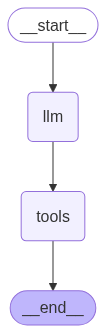

In [14]:
from IPython.display import Image, display
display(Image(tools_graph.get_graph().draw_mermaid_png()))

In [15]:
results = tools_graph.invoke({"messages": "What is Weather like in Hyderabad"})


In [16]:
print(results['messages'][-1].content)


In Hyderabad, the current weather is as follows:
Detailed status: overcast clouds
Wind speed: 7.09 m/s, direction: 246°
Humidity: 55%
Temperature: 
  - Current: 27.83°C
  - High: 27.83°C
  - Low: 27.83°C
  - Feels like: 28.71°C
Rain: {}
Heat index: None
Cloud cover: 94%
